# Lab 13 — Projeto de Compensadores de Avanço e de Atraso na Frequência

**Módulo 03 · Semana 13 · Laboratório de Controle Automático (Ifes Guarapari)**

Neste laboratório você vai:
1. Projetar um **avanço de fase** pelas três fórmulas ($\alpha$, $T$, $K$) e validar;
2. Projetar um **atraso de fase** para matar erro estacionário sem tocar a dinâmica;
3. Combinar os dois (avanço + atraso) para atender **três requisitos** simultâneos.

Teoria de referência: `teoria_modulo3.md`, seção **§3.4** (figuras `m3_fig24` a `m3_fig31`).
Receita de 6 passos do avanço: **§3.4.5**; do atraso: **§3.4.6**.

In [1]:
# %% IMPORTS (rode esta célula primeiro)
!pip install --quiet control==0.10.2
import control as ct
import numpy as np
import matplotlib.pyplot as plt
import math
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True

def step(G, t):
    t, y = ct.step_response(G, t)
    return np.asarray(t), np.asarray(y)   # python-control 0.10.2: converte NamedSignal

def medir(T, t=None):
    # Mede Mp (%), tp, tr(0-100%) e ts(5%) da resposta ao degrau de T.
    if t is None: t = np.linspace(0, 50, 20000)
    t, y = step(T, t)
    yss = y[-1]
    Mp = 100*(y.max() - yss)/yss
    tp = t[np.argmax(y)]
    tr = t[np.argmax(y >= yss)]
    fora = np.where(np.abs(y - yss) > 0.05*abs(yss))[0]
    ts = t[fora[-1]] if len(fora) else 0.0
    return dict(Mp=Mp, tp=tp, tr=tr, ts=ts, yss=yss)

def mp(G, w):
    # Módulo (vezes) e fase (graus) de G em w (rad/s).
    mag, ph, _ = ct.frequency_response(G, np.atleast_1d(w))
    return np.asarray(mag).ravel(), np.degrees(np.asarray(ph).ravel())

def mf(G):
    return ct.feedback(G, 1)

print('python-control', ct.__version__)


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


python-control 0.10.2


## Parte 1 — Avanço de fase: PM e velocidade

**Problema:** $G(s) = \dfrac{0{,}005}{s(s+0{,}05)}$ (planta lenta, tipo 1). Requisitos: $M_p \leq 30\,\%$ e $t_r \leq 16$ s.

**Tradução (§3.4.5):** $M_p \leq 30\,\% \Rightarrow \mathrm{PM}$ alvo $= 40°$; $t_r \approx 1{,}8/\omega_c \leq 16 \Rightarrow \omega_c$ alvo $= 0{,}11$ rad/s (com folga).

In [2]:
G = ct.tf([0.005], [1, 0.05, 0])
wc_alvo = 0.11

# passo 1: planta na ωc alvo
m, p = mp(G, wc_alvo)
PM_atual = p[0] + 180
print(f'Em ωc = {wc_alvo}: |G| = {m[0]:.4f} ({20*np.log10(m[0]):.1f} dB), fase = {p[0]:.1f}° → PM atual = {PM_atual:.1f}°')

# passo 2: fase a avançar (a folga já está na PM alvo — não some duas vezes!)
phi = 40 - PM_atual
print(f'φ = 40° - {PM_atual:.1f}° = {phi:.1f}°')

# passo 3: as três fórmulas do avanço
alpha = (1 - math.sin(math.radians(phi)))/(1 + math.sin(math.radians(phi)))
T = 1/(wc_alvo*math.sqrt(alpha))
K = math.sqrt(alpha)/m[0]
print(f'α = {alpha:.2f},  T = {T:.1f} s (αT = {alpha*T:.1f} s),  K = {K:.2f}')
print(f'zero em -1/T = {-1/T:.3f},  polo em -1/(αT) = {-1/(alpha*T):.3f}')

# compensador (valores arredondados do projeto)
C = 2.1*ct.tf([12, 1], [6.5, 1])
print('\nC(s) ='); print(C)

# verificação
w = np.logspace(-4, 1, 4000)
mc, pc = mp(C*G, w)
mdb = 20*np.log10(mc)
iwc = np.argmin(np.abs(mdb))
print(f'malha compensada: ωc = {w[iwc]:.3f} rad/s,  PM = {pc[iwc]+180:.1f}°')
r = medir(mf(C*G), np.linspace(0, 120, 60000))
print(f'simulação: Mp = {r["Mp"]:.1f}% (≤ 30% ✓),  tr = {r["tr"]:.1f} s (≤ 16 s ✓)')

Em ωc = 0.11: |G| = 0.3762 (-8.5 dB), fase = -155.6° → PM atual = 24.4°
φ = 40° - 24.4° = 15.6°
α = 0.58,  T = 12.0 s (αT = 6.9 s),  K = 2.02
zero em -1/T = -0.084,  polo em -1/(αT) = -0.145

C(s) =
<TransferFunction>: sys[4]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  25.2 s + 2.1
  ------------
   6.5 s + 1
malha compensada: ωc = 0.115 rad/s,  PM = 40.8°


simulação: Mp = 29.6% (≤ 30% ✓),  tr = 15.5 s (≤ 16 s ✓)


### ✏️ Responda no relatório

**Q1.1** Verifique que $\omega_{máx} = 1/(T\sqrt{\alpha}) = 0{,}11$ é a média geométrica de zero e polo do compensador. Por que o pico de fase é colocado **exatamente** na nova $\omega_c$?

**Q1.2** A PM simulada ficou perto dos $40°$ projetados? E o $M_p$ simulado, perto da previsão $\mathrm{PM}\approx100\zeta$? Explique o papel do **zero** do compensador na diferença.

**Q1.3** O que limita o $\phi$ máximo de um único estágio de avanço? (Dica: plote $\phi_{máx} \times \alpha$ — figura `m3_fig27`.) O que fazer se forem precisos $80°$?

## Parte 2 — Atraso de fase: erro estacionário sem estragar a dinâmica

**Problema:** $G(s) = \dfrac{10}{(s+1)(s+2)}$ em malha fechada unitária tem $e_{ss} = 1/6 = 16{,}7\,\%$. Requisito: $e_{ss} \leq 8{,}5\,\%$ **preservando** $M_p$ e $t_r$.

**Mecanismo (§3.4.6):** um par polo/zero **perto da origem**, com $|z|/|p| = $ fator de melhoria do erro, uma década abaixo de $\omega_c$ — em $\omega_c$ o par se cancela; em DC vale $z/p$.

G(0) = 5.0 → kp = 5 → ess = 1/6 = 16.7%
ωc = 2.76 rad/s,  PM = 55.9° (sobrando)
polo em -0.28,  zero em -0.61  (z/p = 2.2)
contribuição do par em ωc: 0.16 dB e -6.7° — pequena, e a PM de 56° absorve ✓



sem C: ess = 0.167,  Mp = 22.1%,  tr = 0.65 s
com C: ess = 0.083,  Mp = 22.6%,  tr = 0.66 s


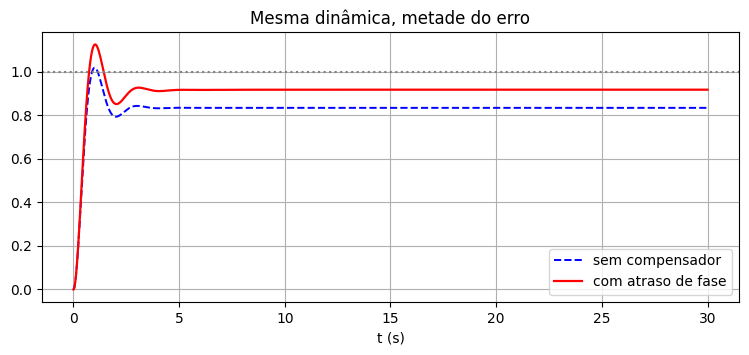

In [3]:
G = ct.tf([10], [1, 3, 2])
print(f'G(0) = {float(ct.dcgain(G)):.1f} → kp = 5 → ess = 1/6 = {1/6*100:.1f}%')

# dinâmica atual
w = np.logspace(-2, 2, 3000)
m, p = mp(G, w)
mdb = 20*np.log10(m)
iwc = np.argmin(np.abs(mdb)); wc = w[iwc]
print(f'ωc = {wc:.2f} rad/s,  PM = {p[iwc]+180:.1f}° (sobrando)')

# projeto: ess = 1/12 = 8,3% → kpc = 11 → z/p = 11/5 = 2,2
p_atraso = wc/10
z_atraso = 2.2*p_atraso
C = ct.tf([1, z_atraso], [1, p_atraso])
print(f'polo em -{p_atraso:.2f},  zero em -{z_atraso:.2f}  (z/p = {z_atraso/p_atraso:.1f})')

# o par some em ωc?
mC, pC = mp(C, wc)
print(f'contribuição do par em ωc: {20*np.log10(mC[0]):.2f} dB e {pC[0]:.1f}° — pequena, e a PM de 56° absorve ✓')

t = np.linspace(0, 30, 60000)
r0 = medir(mf(G), t); rc = medir(mf(C*G), t)
print(f'\nsem C: ess = {1-r0["yss"]:.3f},  Mp = {r0["Mp"]:.1f}%,  tr = {r0["tr"]:.2f} s')
print(f'com C: ess = {1-rc["yss"]:.3f},  Mp = {rc["Mp"]:.1f}%,  tr = {rc["tr"]:.2f} s')

tt, y0 = step(mf(G), t); _, yc = step(mf(C*G), t)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(tt, y0, 'b--', lw=1.4, label='sem compensador')
ax.plot(tt, yc, 'r', lw=1.6, label='com atraso de fase')
ax.axhline(1, color='gray', ls=':')
ax.set_xlabel('t (s)'); ax.legend(); ax.set_title('Mesma dinâmica, metade do erro')
plt.show()

### ✏️ Responda no relatório

**Q2.1** Mostre na mão que o erro cai de $1/6$ para $1/12$ com o compensador (calcule o novo $k_p$).

**Q2.2** Por que o par foi colocado em $-\omega_c/10$ e não, digamos, em $-\omega_c/2$? O que aconteceria com a PM no segundo caso?

**Q2.3** Qual a diferença conceitual entre o atraso de fase e o PI? (Consulte §3.4.6 e §3.5.2.)

## Parte 3 — Avanço + atraso: três requisitos de uma vez

**Problema (âncora da teoria, §3.4.7):** $G(s) = \dfrac{1}{(s+5)(s+10)}$. Requisitos: $M_p \leq 10\,\%$, $t_r \leq 0{,}1$ s, $e_{ss} \leq 6\,\%$.

**Estratégia:** o **avanço** cuida de $M_p$ e $t_r$ (PM alvo $= 60°$ em $\omega_c = 27$ rad/s); o **atraso** cuida do $e_{ss}$ (dobra o ganho DC sem mexer em $\omega_c$).

avanço: PM atual = 30.8°, φ = 34° → α = 0.28, T = 0.07 (αT = 0.020), K = 419
kp compensado = 16.8 → ess previsto = 0.056



sem C: Mp = 0.0%,  ts(5%) = 0.72 s,  ess = 0.980  (lento e com erro enorme)
com C: Mp = 7.0%,  tr = 0.076 s,  ess = 0.056


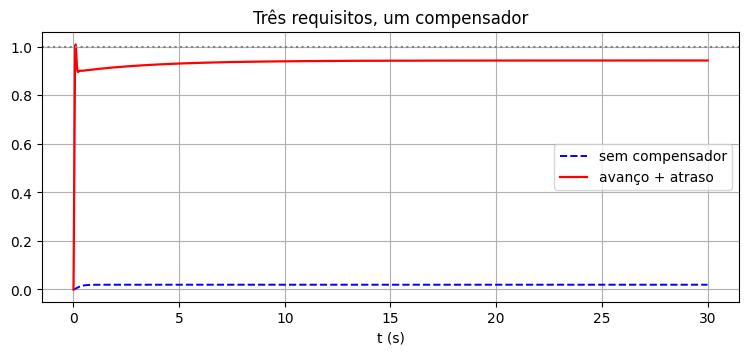

In [4]:
G = ct.tf([1], [1, 15, 50])
wc_alvo = 27.0

# --- estágio de avanço ---
m, p = mp(G, wc_alvo)
PM_atual = p[0] + 180
phi = 60 - PM_atual + 5     # folga de 5°: o atraso vai "gastar" um pouco de PM
alpha = (1 - math.sin(math.radians(phi)))/(1 + math.sin(math.radians(phi)))
T = 1/(wc_alvo*math.sqrt(alpha))
K = math.sqrt(alpha)/m[0]
print(f'avanço: PM atual = {PM_atual:.1f}°, φ = {phi:.0f}° → α = {alpha:.2f}, T = {T:.2f} (αT = {alpha*T:.3f}), K = {K:.0f}')
C1 = 420*ct.tf([0.07, 1], [0.021, 1])

# --- estágio de atraso: ess ≤ 6% → kpc ≥ 15,7; com C1: kp = 420/50 = 8,4 → falta 2×
C2 = ct.tf([1, 0.28], [1, 0.14])   # z/p = 2, polo em ≈ -ωc/200
C = C1*C2

print(f'kp compensado = {float(ct.dcgain(C*G)):.1f} → ess previsto = {1/(1+float(ct.dcgain(C*G))):.3f}')

t_long = np.linspace(0, 30, 60000)   # horizonte longo: o atraso cria cauda lenta (τ ≈ 1/0,14 s)
r0 = medir(mf(G), t_long); rc = medir(mf(C*G), t_long)
print(f'\nsem C: Mp = {r0["Mp"]:.1f}%,  ts(5%) = {r0["ts"]:.2f} s,  ess = {1-r0["yss"]:.3f}  (lento e com erro enorme)')
print(f'com C: Mp = {rc["Mp"]:.1f}%,  tr = {rc["tr"]:.3f} s,  ess = {1-rc["yss"]:.3f}')

tt, y0 = step(mf(G), t); _, yc = step(mf(C*G), t)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(tt, y0, 'b--', lw=1.4, label='sem compensador')
ax.plot(tt, yc, 'r', lw=1.6, label='avanço + atraso')
ax.axhline(1, color='gray', ls=':')
ax.set_xlabel('t (s)'); ax.legend(); ax.set_title('Três requisitos, um compensador')
plt.show()

### ✏️ Responda no relatório

**Q3.1** Refaça na mão as contas do estágio de avanço ($\alpha$, $T$, $K$) — os valores arredondados ($T = 0{,}07$, $K = 420$) estão coerentes?

**Q3.2** Por que o polo do atraso foi colocado em $-\omega_c/200$ e não em $-\omega_c/10$? (Dica: quanto custa cada opção em PM?)

**Q3.3** Some os efeitos: qual foi o papel de **cada** estágio no resultado final? O que falharia se usássemos só o avanço? Só o atraso?

---

## Encerramento

Você projetou os dois compensadores clássicos **sem desenhar um único LGR**: o avanço reposiciona $\omega_c$ e devolve PM; o atraso multiplica o ganho DC sem ser visto pela dinâmica. No Lab 14, a versão "industrial" dessas ideias: PD, PI e PID.